**Prompt**

We surveyed the night sky and measured spectra of several galaxies. In some of these galaxies, we identified Cepheid variable stars. A separate group of astronomers established that for Cepheid variables, the relation between absolute magnitude $M$ and period $P$ in days is:

$$M = -2.43 \cdot (\log(P) - 1) - 4.05$$

Provided data contains measured spectra of several galaxies and information about Cepheids in these galaxies, if they were available. There is at most one Cepheid per galaxy. Analysis of the measured spectra verified that the observed spectra contain only lines that were observed in the laboratory. Use the provided dataset to determine Hubble's constant, incorporating all available data. Apply unweighted linear regression with the intercept fixed at the origin, consistent with the physical expectation that recession velocity vanishes at zero distance. Assume the relativistic Doppler formula for computing velocities from redshifts. For redshift extraction, identify observed lines with the lines in the laboratory reference spectrum, then estimate the redshift from the line with the largest laboratory wavelength present in the observed spectrum to minimize reading error. When reading the wavelength assume that the brightness profile of the line can be modelled by normal distribution and the wavelength of the line is the mean of the distribution.

Provide the following output files:

1) A .pdf file containing a list of only those galaxies for which a spectroscopic measurement exists in the dataset and which also have a Cepheid variable allowing their distance to be determined. The list should state the redshift of each galaxy in the list and be ordered by the galaxy ID.

2) A scatter plot in .png file showing the recession velocity of each galaxy as a function of the distance estimated from its Cepheid variable. The plot should include a physically motivated fit of Hubble's law, with the fitted equation stated quantitatively.

3) A .txt file with clearly stated value of Hubble's constant from this data set, including the statistical uncertainty.

**This is data generation**

*About the data: I created the dataset of emission spectra of multiple galaxies. I used python matplotlib library for creating images. Data are simulated by using tabulated data of some of the brightest spectral lines in the range of 400-750 nm. The brightness profile of these lines is approximated by normal distribution. These spectra were then shifted according to Doppler effect for each of the hypothetical galaxy. Redshifts of these galaxies come from the uniform distribution. The dataset also contains simulated apparent magnitudes and periods of hypothetical Cepheid variables in these galaxies. I modelled these numbers to match possibly measured values using Poggson's equation and Hubble's law, in order to get physically realistic result of the Hubble's constant. Finally, I smeared the data by normal distribution.*

In [4]:
import numpy as np
import random
import pandas as pd
import string
import math
import matplotlib.pyplot as plt
import os
import shutil
from matplotlib.ticker import MultipleLocator, FuncFormatter

#Path to save outputs
path = "/Users/ondra/Outlier/SpideyMM_project/galaxies_spectra/input_data/"
os.chdir(path)
spectra_folder = 'spectra'
shutil.rmtree(spectra_folder)
os.makedirs(spectra_folder)

#Input parameters
random.seed(42)
c = 299792.458 #km/s
SIGMA_DISTANCE_CEPHEIDES = 0.1
Z_MAX = 0.05
N_GALAXIES = 10
H = 67
CEPHEID_GENERATE_PROBABILITY = 1
GALAXY_GENERATE_PROBABILITY = 1

# Laboratory spectrum
LAB_SPECTRUM = {656.3: 1.0, 500.7: 0.9, 589.0: 0.85, 589.6: 0.8, 486.1: 0.75, 495.9: 0.65, 587.6: 0.6, 658.3: 0.55, 654.8: 0.5, 434.0: 0.45, 671.6: 0.38, 673.1: 0.34, 410.2: 0.3, 667.8: 0.27, 630.0: 0.23, 518.4: 0.2, 447.1: 0.17, 422.7: 0.15, 636.4: 0.12, 438.3: 0.1}

#Dataframe format
df = pd.DataFrame({ 'index': pd.Series(dtype='int'),
                    'galaxy_ID': pd.Series(dtype='str'),
                    'z' : pd.Series(dtype='float'),
                    'spectrum' : pd.Series(dtype='object'),
                    'true_distance [pc]' : pd.Series(dtype='float'),
                    'cepheid_ID': pd.Series(dtype='str'),
                    'cepheid_distance [pc]' : pd.Series(dtype='float'),
                    'mean_mag_cepheid': pd.Series(dtype='float'),
                    'period [days]': pd.Series(dtype='float'),})

def plot_spectrum(input_spectrum : dict[float, float], title: str = '', name : str = '', save_to: str = path) -> None:
    def gaussian(x, mu, sigma, amplitude):
        return amplitude * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

    wavelength = np.linspace(400, 750, 7000)
    intensity = np.zeros_like(wavelength)
    for mu, amp in input_spectrum.items():
        intensity += gaussian(wavelength, mu, sigma=0.1, amplitude=amp)
    intensity /= intensity.max()

    image = np.tile(intensity, (80, 1))

    fig, ax = plt.subplots(figsize=(14, 2))
    ax.imshow(image, cmap='gray', aspect='auto', extent=[wavelength[0], wavelength[-1], 0, 1])
    ax.set_title(f"{title}")
    ax.set_yticks([])
    ax.set_xlabel("Wavelength (nm)")

    # Major ticks every 10 nm (longer)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    # Minor ticks every 1 nm (shorter)
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    # Set tick lengths
    ax.tick_params(axis='x', which='major', length=8)
    ax.tick_params(axis='x', which='minor', length=4)

    # Labels only at multiples of 50 using FuncFormatter
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x)}' if x % 50 == 0 else ''))

    plt.tight_layout()
    plt.savefig(f"{save_to}/{name}.png", dpi=150, bbox_inches="tight")
    plt.close()
    #plt.show()

plot_spectrum(LAB_SPECTRUM, 'Spectrum from the laboratory (400 - 750 nm)', "spectral_lines_lab", save_to=path)

#def generate_lightcurve(period: float, mean_mag: float):

#Generate data
for i in range(N_GALAXIES):
    index = i
    galaxy_ID = 'GID' + ''.join(random.choices(string.digits, k=6))

    if np.random.uniform(0,1) < GALAXY_GENERATE_PROBABILITY:
        z = random.uniform(0.2,1)*Z_MAX
        LINE_VISIBLE_PROBABILITY = 0.5
        spectrum = {}
        for line in LAB_SPECTRUM.keys():
            shifted_line = line * (z + 1)
            if random.uniform(0,1) < LINE_VISIBLE_PROBABILITY:
                spectrum[shifted_line] = LAB_SPECTRUM[line]
        plot_spectrum(spectrum, f"Observed spectrum - {galaxy_ID}", galaxy_ID, path + spectra_folder)
    else:
        z = np.nan
        spectrum = {}

    true_distance = float(z*c/H * 10**6)
    if np.random.uniform(0,1) < CEPHEID_GENERATE_PROBABILITY and not np.isnan(z):
        cepheid_ID = 'HDD' + ''.join(random.choices(string.digits, k=6))
        cepheid_distance = np.random.normal(loc=true_distance, scale=true_distance*SIGMA_DISTANCE_CEPHEIDES) #pc
        period = abs(np.random.normal(loc=60, scale=20))
        mean_mag = -2.43*(math.log10(period) - 1) - 4.05 - 5 + 5*math.log10(cepheid_distance)
    else:
        cepheid_ID = np.nan
        cepheid_distance = np.nan
        period = np.nan
        mean_mag = np.nan

    new_row = pd.DataFrame([{'index' : index,
                             'galaxy_ID' : galaxy_ID,
                             'z' : z,
                             'spectrum' : spectrum,
                             'true_distance [pc]' : true_distance,
                             'cepheid_ID' : cepheid_ID,
                             'cepheid_distance [pc]' : cepheid_distance,
                             'mean_mag_cepheid' : mean_mag,
                             'period [days]' : period}])
    df = pd.concat([df, new_row], ignore_index=True)

#Print data that can be estimated
df_est = df.copy()
df_est['z'] = df['z'].round(4)
df_est['mean_mag_cepheid'] = df['mean_mag_cepheid'].round(3)
df_est['period [days]'] = df['period [days]'].round(4)

#Print cepheides to .csv file
df_out = df_est.copy()
df_out['mean_mag_cepheid']                    = df_est['mean_mag_cepheid'].map('{:.3f}'.format)
df_out['period [days]'] = df_est['period [days]'].map('{:.4f}'.format)
df_out[['galaxy_ID' , 'cepheid_ID', 'mean_mag_cepheid', 'period [days]']].to_csv(path + "/cepheides_mesurements.csv", index=False)

#zip files to submission file
import shutil
os.chdir(path + "../")
shutil.make_archive(
    base_name='input_data',   # name of the zip file (without .zip)
    format='zip',
    root_dir='.',         # directory to start from
    base_dir='input_data'  # folder to zip
)

df

,index,galaxy_ID,z,spectrum,true_distance [pc],cepheid_ID,cepheid_distance [pc],mean_mag_cepheid,period [days]
0,0,GID602276,0.045687,"{686.2844980113875: 1.0, 523.5755723819926: 0....",2.044280e+08,HDD086875,2.076671e+08,30.788284,52.428749
1,1,GID935868,0.033094,"{517.2702087652024: 0.9, 608.4924165422493: 0....",1.480800e+08,HDD965687,1.612793e+08,29.816594,78.259844
2,2,GID203229,0.045055,"{685.8694029301604: 1.0, 615.537221279696: 0.8...",2.015979e+08,HDD403959,2.482091e+08,32.015833,23.646539
3,3,GID807652,0.035638,"{679.6895291363171: 1.0, 518.5441829019564: 0....",1.594649e+08,HDD098830,1.769987e+08,29.986775,80.652096
4,4,GID890407,0.040633,"{682.967685438167: 1.0, 521.0451319501603: 0.9...",1.818146e+08,HDD206298,1.342363e+08,30.909363,19.047160
5,5,GID026219,0.032842,"{677.8540232859754: 1.0, 608.9634803129835: 0....",1.469508e+08,HDD294850,1.585149e+08,30.031172,61.628983
6,6,GID989981,0.029426,"{675.6120508253323: 1.0, 515.433420460527: 0.9...",1.316655e+08,HDD558190,1.345406e+08,29.853810,52.028045
7,7,GID156218,0.019849,"{600.6908335939: 0.85, 599.2630455344239: 0.6,...",8.881291e+07,HDD298831,8.745877e+07,28.929763,51.478627
8,8,GID876960,0.042684,"{684.313617755051: 1.0, 614.766583922563: 0.8,...",1.909909e+08,HDD762754,2.321125e+08,30.833833,63.135189
9,9,GID008958,0.033300,"{678.15504113949: 1.0, 517.3735015976575: 0.9,...",1.490030e+08,HDD073988,1.368299e+08,29.352648,86.607233


**This is the solution**

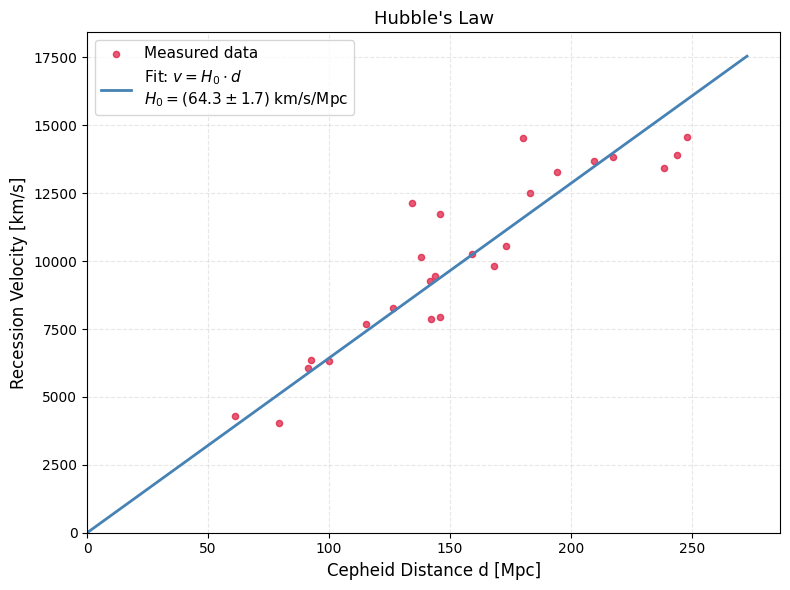

In [2]:
 import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

df_filtered = df_out.loc[df_out['z'].notna() & df_out['cepheid_ID'].notna()].copy()
df_filtered.sort_values(by='galaxy_ID', ascending=True, inplace=True)
df_out_pdf = df_filtered[['galaxy_ID', 'z']].reset_index(drop=True)

with PdfPages(path + "../golden_solution/redshifts.pdf") as pdf:
    fig, ax = plt.subplots(figsize=(6, len(df_out_pdf) * 0.3 + 1))
    ax.axis('off')
    table = ax.table(
        cellText=df_out_pdf.values,
        colLabels=df_out_pdf.columns,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(True)
    table.scale(1, 1.4)
    for (row, col), cell in table.get_celld().items():
        if row == 0:  # header row
            cell.set_text_props(fontweight='bold')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

def plot_hubble(df: pd.DataFrame) -> None:
    mask = df['cepheid_distance [pc]'].notna() & df['z'].notna()
    x = df.loc[mask, 'cepheid_distance [pc]'] / 1e6
    y = c * ((df.loc[mask, 'z'] + 1)**2 -1)/((df.loc[mask, 'z'] + 1)**2 + 1)
    #y = df.loc[mask, 'z'].round(2) * c

    # Fit through zero and its standard error
    H0        = np.sum(x * y) / np.sum(x ** 2)
    residuals = y - H0 * x
    H0_err    = np.sqrt(np.sum(residuals ** 2) / ((len(x) - 1) * np.sum(x ** 2)))

    x_fit = np.linspace(0, x.max() * 1.1, 200)
    y_fit = H0 * x_fit

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(x, y, s=20, alpha=0.7, color='crimson', label='Measured data')
    ax.plot(x_fit, y_fit, color='steelblue', lw=2,
            label=f'Fit: $v = H_0 \\cdot d$\n$H_0 = ({H0:.1f} \\pm {H0_err:.1f})$ km/s/Mpc')

    with open(path + '../golden_solution/hubbles_constant.txt', 'w') as f:
        print(f"The Hubble's constant estimated from the presented dataset is {H0:.1f} ± {H0_err:.1f} km/s/Mpc.", file=f)

    ax.set_xlabel('Cepheid Distance d [Mpc]', fontsize=12)
    ax.set_ylabel('Recession Velocity [km/s]', fontsize=12)
    ax.set_title("Hubble's Law", fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(0, None)
    ax.set_ylim(0, None)

    plt.tight_layout()
    plt.savefig(path + '../golden_solution/hubble_law.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_hubble(df_est)